Dataset
↓
Train/Test Split
↓
SMOTE ONLY on X_train
↓
Train
↓
Evaluate on untouched X_test

In [2]:
from imblearn.over_sampling import (
    SMOTE,
    BorderlineSMOTE,
    ADASYN
)

from imblearn.combine import SMOTEENN

from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/feature_engineered.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [4]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42,
    test_size=0.2
)

# Identify Feature Types

In [5]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

C:\Users\sansi\AppData\Local\Temp\ipykernel_30936\2825086182.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


## Build Processor

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

## Evaluation Function

In [7]:
def evaluate_model(name, model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob)
    }

In [14]:
from sklearn.linear_model import LogisticRegression

original_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

original_pipeline.fit(X_train, y_train)

original_results = evaluate_model(
    "Original",
    original_pipeline,
    X_test,
    y_test
)

## SMOTE

In [15]:
smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

smote_pipeline.fit(X_train, y_train)

smote_results = evaluate_model(
    "SMOTE",
    smote_pipeline,
    X_test,
    y_test
)

## Borderline-SMOTE

In [16]:
borderline_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", BorderlineSMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

borderline_pipeline.fit(X_train, y_train)

borderline_results = evaluate_model(
    "Borderline SMOTE",
    borderline_pipeline,
    X_test,
    y_test
)

## ADASYN

In [17]:
adasyn_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("adasyn", ADASYN(random_state=42)),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

adasyn_pipeline.fit(X_train, y_train)

adasyn_results = evaluate_model(
    "ADASYN",
    adasyn_pipeline,
    X_test,
    y_test
)

## SMOTEENN

In [18]:
smoteenn_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smoteenn", SMOTEENN(random_state=42)),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

smoteenn_pipeline.fit(X_train, y_train)

smoteenn_results = evaluate_model(
    "SMOTEENN",
    smoteenn_pipeline,
    X_test,
    y_test
)

# Compare

In [19]:
results = pd.DataFrame([
    original_results,
    smote_results,
    borderline_results,
    adasyn_results,
    smoteenn_results
])

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Original,0.793177,0.630915,0.534759,0.578871,0.834679,0.624374
1,SMOTE,0.737740,0.504333,0.778075,0.611987,0.832476,0.621519
2,Borderline SMOTE,0.692964,0.457602,0.836898,0.591682,0.827310,0.606419
3,ADASYN,0.707889,0.471669,0.823529,0.599805,0.829994,0.615736
4,SMOTEENN,0.675906,0.443213,0.855615,0.583942,0.828770,0.607924


## Visualize

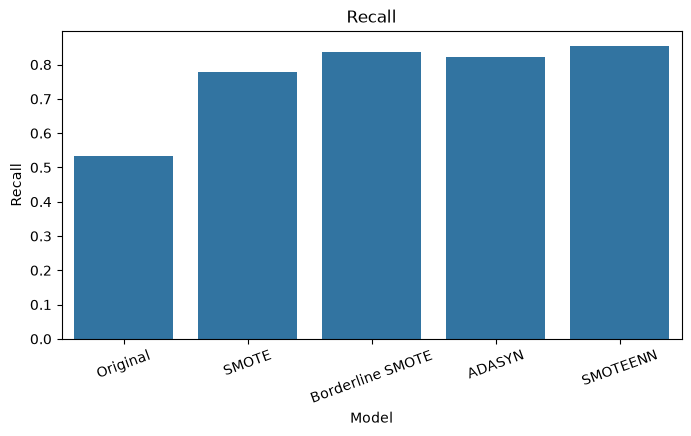

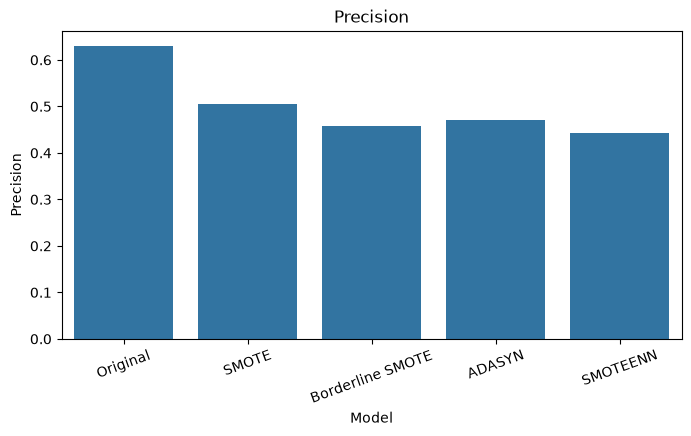

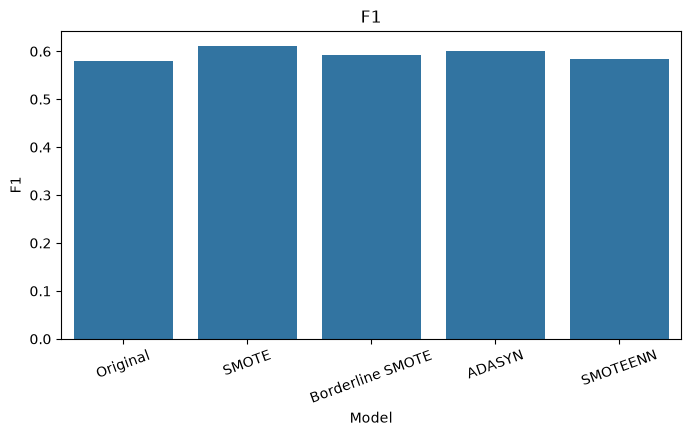

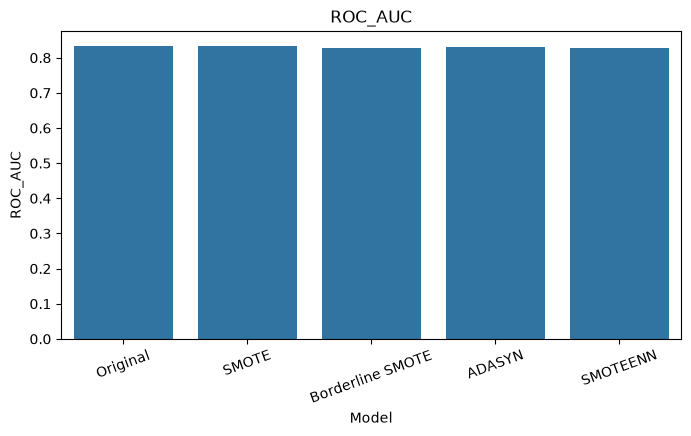

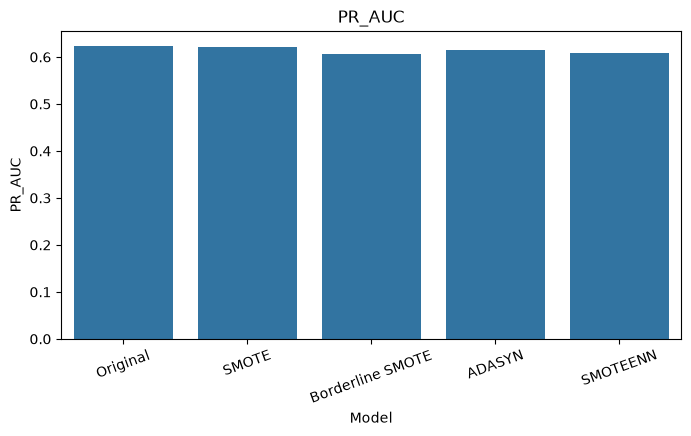

In [20]:
import seaborn as sns

metrics = [
    "Recall",
    "Precision",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

for metric in metrics:

    plt.figure(figsize=(8,4))

    sns.barplot(
        data=results,
        x="Model",
        y=metric
    )

    plt.title(metric)

    plt.xticks(rotation=20)

    plt.show()

In [ ]:
best_model = smote_pipeline
best_method = "SMOTE"

import joblib

joblib.dump(
    best_model,
    "../models/smote_logistic_regression.pkl"
)

['../models/best_smote_model.pkl']

In [1]:
best_resampling_model = smote_pipeline

NameError: name 'smote_pipeline' is not defined

# Analysis of Resampling Techniques

The performance of Logistic Regression was evaluated using multiple resampling techniques to address class imbalance.

### Original Model

The baseline Logistic Regression achieved the highest Accuracy (79.3%), Precision (63.1%), ROC-AUC (0.835), and PR-AUC (0.624). However, it detected only 53.5% of customers who actually churned.

### SMOTE

SMOTE significantly improved Recall from 53.5% to 77.8% while achieving the highest F1-score (0.612). Although Accuracy and Precision decreased slightly, the model became much better at identifying churning customers.

### Borderline-SMOTE

Borderline-SMOTE further increased Recall but caused a considerable reduction in Precision and Accuracy, indicating more false positive predictions.

### ADASYN

ADASYN achieved similar Recall improvements to Borderline-SMOTE while maintaining a slightly better balance between Precision and Recall.

### SMOTEENN

SMOTEENN produced the highest Recall (85.6%), indicating that it identified the largest number of churning customers. However, this improvement came at the expense of significantly lower Precision and Accuracy, leading to many false alarms.

## Conclusion

Among all evaluated resampling techniques, SMOTE provided the best overall balance between detecting churning customers and maintaining predictive performance.

Although the original Logistic Regression model achieved the highest Accuracy and Precision, its Recall was relatively low, meaning that many churning customers would remain undetected.

SMOTE substantially improved Recall while preserving competitive ROC-AUC and PR-AUC values and achieving the highest F1-score. Therefore, SMOTE was selected as the preferred resampling technique for subsequent experiments.

# Summary

- Built Logistic Regression as the baseline classifier.
- Compared five imbalance handling strategies:
  - Original Data
  - SMOTE
  - Borderline-SMOTE
  - ADASYN
  - SMOTEENN
- Evaluated each model using Accuracy, Precision, Recall, F1-score, ROC-AUC, and PR-AUC.
- Observed that resampling techniques significantly improved Recall at the cost of reduced Precision and Accuracy.
- Selected SMOTE as the preferred resampling method because it achieved the highest F1-score while maintaining competitive ROC-AUC and PR-AUC values.
- Saved the SMOTE pipeline for future experiments.